In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fitness_log.csv')

print(df.shape)        # how many rows and columns
print(df.head(10))     # first 10 rows
print(df.info())       # data types — are numbers actually stored as numbers?
print(df.describe())   # min, max, mean, std for every column

(40, 5)
   hours_slept  workout_intensity  core_minutes  protein_grams  \
0          7.5                  8            20          145.0   
1          6.8                  6            15          120.5   
2          8.0                  9            25          160.0   
3          5.9                  4            10           95.0   
4          7.2                  7            18          135.0   
5          6.5                  5            12          110.0   
6          8.3                  9            30          170.0   
7          7.0                  6            15          125.0   
8          5.5                  3             5           85.0   
9          7.8                  8            22          150.0   

  next_day_readiness  
0     Heavy Training  
1    Active Recovery  
2     Heavy Training  
3               Rest  
4     Heavy Training  
5    Active Recovery  
6     Heavy Training  
7    Active Recovery  
8               Rest  
9     Heavy Training  
<class 'pand

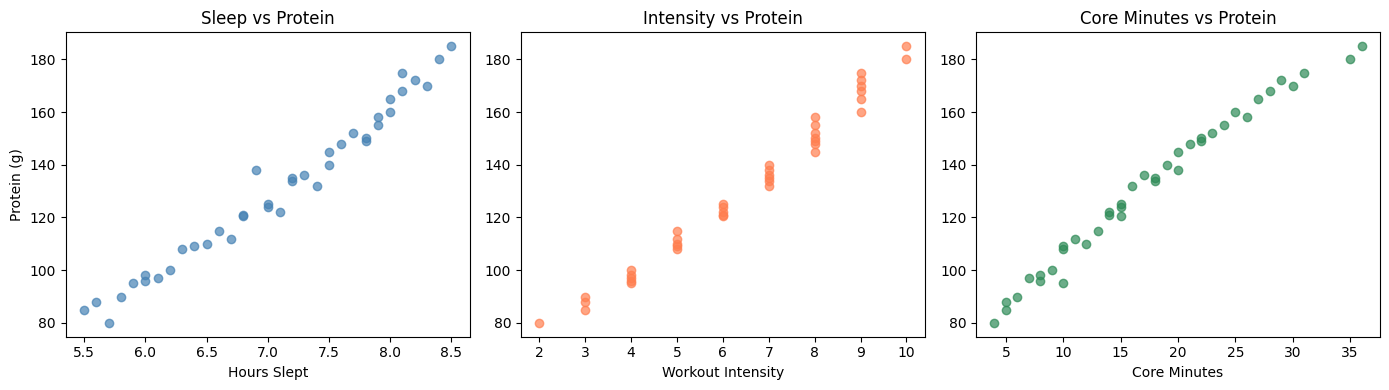

                   hours_slept  workout_intensity  core_minutes  protein_grams
hours_slept           1.000000           0.984131      0.965908       0.986571
workout_intensity     0.984131           1.000000      0.971359       0.990141
core_minutes          0.965908           0.971359      1.000000       0.990319
protein_grams         0.986571           0.990141      0.990319       1.000000


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(df['hours_slept'], df['protein_grams'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Hours Slept')
axes[0].set_ylabel('Protein (g)')
axes[0].set_title('Sleep vs Protein')

axes[1].scatter(df['workout_intensity'], df['protein_grams'], color='coral', alpha=0.7)
axes[1].set_xlabel('Workout Intensity')
axes[1].set_title('Intensity vs Protein')

axes[2].scatter(df['core_minutes'], df['protein_grams'], color='seagreen', alpha=0.7)
axes[2].set_xlabel('Core Minutes')
axes[2].set_title('Core Minutes vs Protein')

plt.tight_layout()
plt.show()

print(df[['hours_slept', 'workout_intensity', 'core_minutes', 'protein_grams']].corr())

In [21]:
X = df[['hours_slept', 'workout_intensity', 'core_minutes']]
y = df['protein_grams']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held back for testing
    random_state=42     # fixed seed so results are reproducible
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

Training rows: 32
Testing rows:  8


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()    #remember the syntax
model.fit(X_train, y_train)

feature_names = ['hours_slept', 'workout_intensity', 'core_minutes']

print("Intercept (b):", round(model.intercept_, 2))
print("\nFeature weights:")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name}: {round(coef, 3)}")

Intercept (b): 21.54

Feature weights:
  hours_slept: 7.43
  workout_intensity: 5.032
  core_minutes: 1.376


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {round(mae, 2)} grams")
print(f"RMSE: {round(rmse, 2)} grams")
print(f"R²:   {round(r2, 3)}")

MAE:  2.18 grams
RMSE: 2.78 grams
R²:   0.991


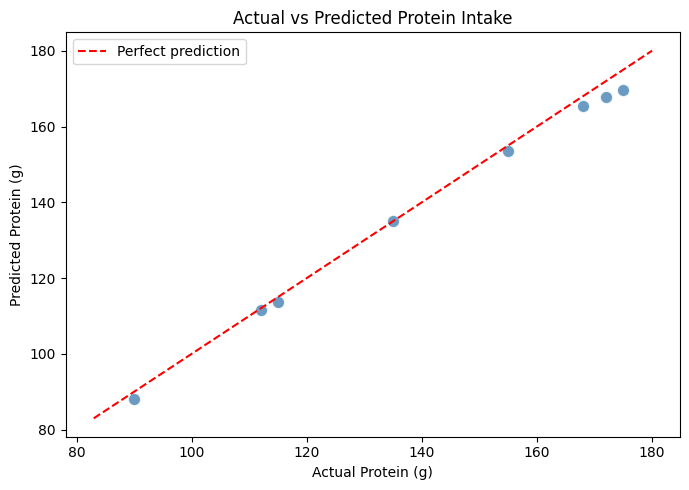

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.8, edgecolors='white', s=80)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min()) - 5
max_val = max(y_test.max(), y_pred.max()) + 5
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual Protein (g)')
plt.ylabel('Predicted Protein (g)')
plt.title('Actual vs Predicted Protein Intake')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
new_day = pd.DataFrame({
    'hours_slept':       [7.0],
    'workout_intensity': [8],
    'core_minutes':      [20]
})

predicted_protein = model.predict(new_day)
print(f"Predicted protein intake: {round(predicted_protein[0], 1)}g")

Predicted protein intake: 141.3g


In [26]:
y_tree = df['next_day_readiness']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y_tree,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(X_train_t, y_train_t)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

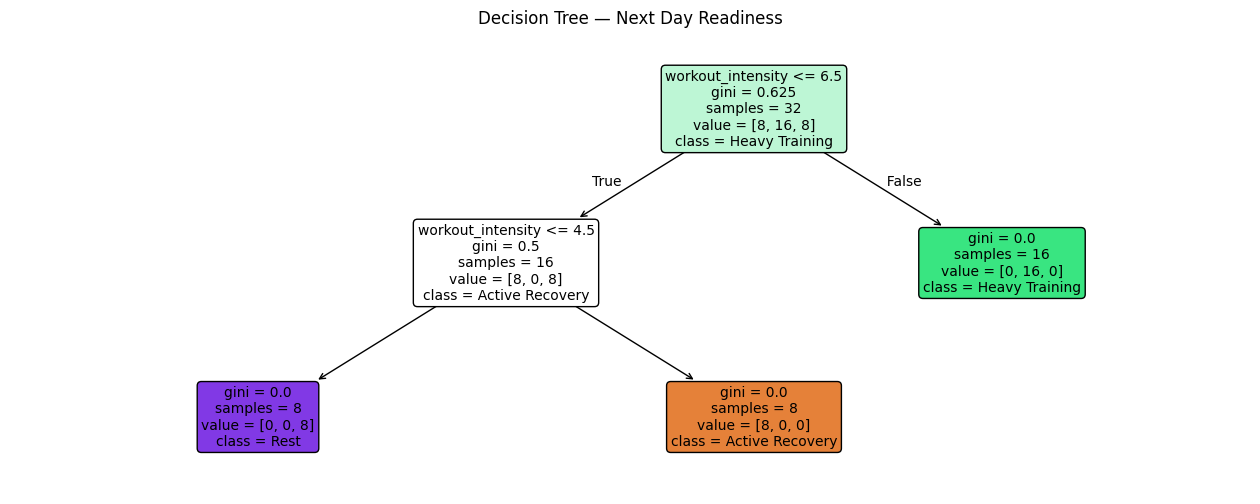

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plot_tree(
    tree_model,
    feature_names=['hours_slept', 'workout_intensity', 'core_minutes'],
    class_names=['Active Recovery', 'Heavy Training', 'Rest'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree — Next Day Readiness")
plt.show()

In [29]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_tree = tree_model.predict(X_test_t)

print("Accuracy:", accuracy_score(y_test_t, y_pred_tree))
print("\nDetailed Report:")
print(classification_report(y_test_t, y_pred_tree))

Accuracy: 1.0

Detailed Report:
                 precision    recall  f1-score   support

Active Recovery       1.00      1.00      1.00         2
 Heavy Training       1.00      1.00      1.00         5
           Rest       1.00      1.00      1.00         1

       accuracy                           1.00         8
      macro avg       1.00      1.00      1.00         8
   weighted avg       1.00      1.00      1.00         8



In [30]:
importances = tree_model.feature_importances_
feature_names = ['hours_slept', 'workout_intensity', 'core_minutes']

for name, score in zip(feature_names, importances):
    print(f"{name}: {round(score, 3)}")

hours_slept: 0.0
workout_intensity: 1.0
core_minutes: 0.0


In [31]:
new_day = pd.DataFrame({
    'hours_slept':       [5.0],
    'workout_intensity': [6],
    'core_minutes':      [8]
})

prediction = tree_model.predict(new_day)
print("Predicted readiness:", prediction[0])

Predicted readiness: Active Recovery


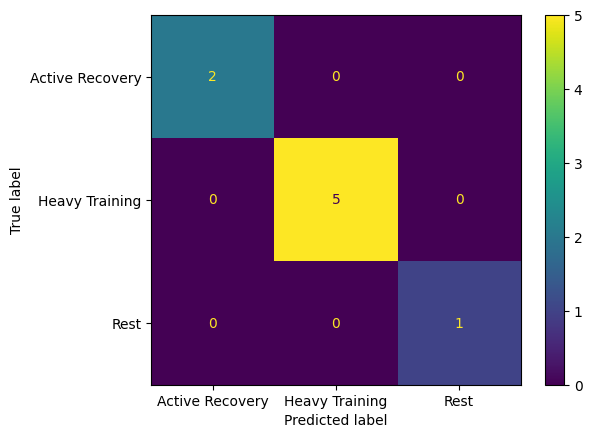

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_t, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
       display_labels=['Active Recovery','Heavy Training','Rest'])
disp.plot()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=3,         # max depth of each individual tree
    random_state=42
)

rf_model.fit(X_train_t, y_train_t)
y_pred_rf = rf_model.predict(X_test_t)

print("Accuracy:", accuracy_score(y_test_t, y_pred_rf))
print(classification_report(y_test_t, y_pred_rf))

Accuracy: 1.0
                 precision    recall  f1-score   support

Active Recovery       1.00      1.00      1.00         2
 Heavy Training       1.00      1.00      1.00         5
           Rest       1.00      1.00      1.00         1

       accuracy                           1.00         8
      macro avg       1.00      1.00      1.00         8
   weighted avg       1.00      1.00      1.00         8



In [34]:
importances = rf_model.feature_importances_
for name, score in zip(['hours_slept', 'workout_intensity', 'core_minutes'], importances):
    print(f"{name}: {round(score, 3)}")

hours_slept: 0.346
workout_intensity: 0.373
core_minutes: 0.28


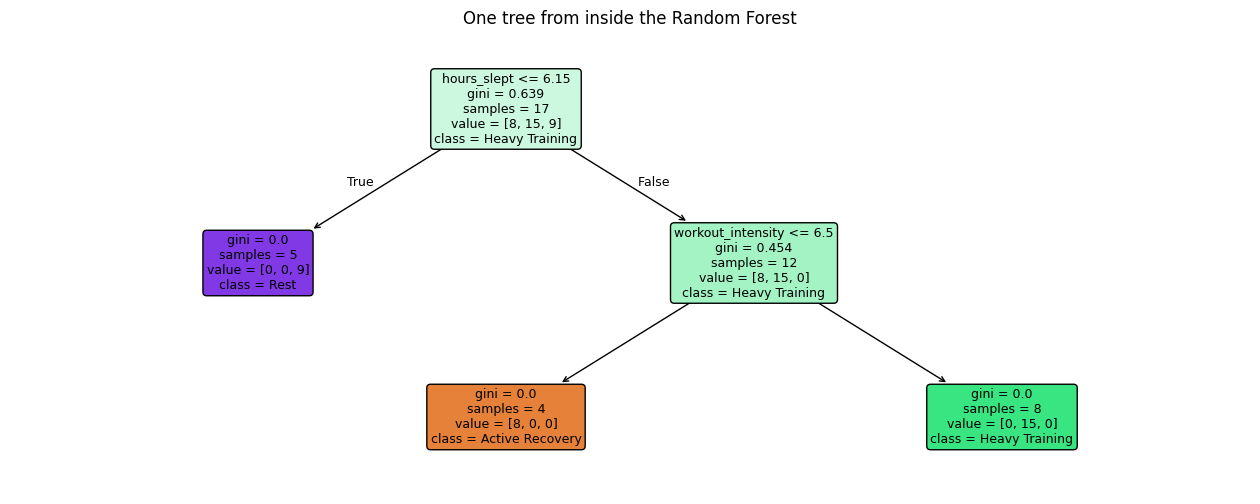

In [35]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plot_tree(
    rf_model.estimators_[0],   # just the first tree
    feature_names=['hours_slept', 'workout_intensity', 'core_minutes'],
    class_names=['Active Recovery', 'Heavy Training', 'Rest'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("One tree from inside the Random Forest")
plt.show()

In [36]:
import joblib

joblib.dump(model, 'backend/linear_model.pkl')
print("Linear model saved!")

Linear model saved!


In [37]:
from sklearn.tree import DecisionTreeClassifier


y_class = df['next_day_readiness']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_c, y_train_c)

print("Decision Tree accuracy:", dt_model.score(X_test_c, y_test_c))

# Save it
joblib.dump(dt_model, 'backend/dt_model.pkl')
print("Decision Tree model saved!")

Decision Tree accuracy: 1.0
Decision Tree model saved!


In [38]:
from sklearn.linear_model import LogisticRegression as LogReg

lr_model = LogReg(max_iter=1000)
lr_model.fit(X_train_c, y_train_c)

print("Logistic Regression accuracy:", lr_model.score(X_test_c, y_test_c))

joblib.dump(lr_model, 'backend/lr_model.pkl')
print("Logistic Regression model saved!")

Logistic Regression accuracy: 1.0
Logistic Regression model saved!
